# Octree Resampling Demo: Inclined Plane and Sphere

This notebook demonstrates Cartesian-octree resampling of density (`rho`) to:

- an inclined plane (`u-v` parameter grid)
- a spherical surface (`theta-phi` parameter grid)

Both sections use one shared `OctreeInterpolator` instance and plot `log10(rho)` with matplotlib.


In [1]:
from pathlib import Path
import sys


def repo_root() -> Path:
    """Find repository root by locating local package/data folders."""
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / "example_data").is_dir() and (candidate / "batcamp").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate repository root with example_data/ and batcamp/.")


REPO_ROOT = repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
from starwinds_readplt.dataset import Dataset

from batcamp import Octree
from batcamp import OctreeInterpolator
from batcamp import format_octree_summary


def data_file(name: str) -> Path:
    """Return path under local example_data directory."""
    return REPO_ROOT / "example_data" / name

np.set_printoptions(precision=5, suppress=True)


## Build Dataset, Octree, and Interpolator

The file below is a Cartesian 3D sample. We build the tree once and reuse it for all queries.


In [2]:
data_path = data_file('3d__var_3_n00004000.dat')
ds = Dataset.from_file(str(data_path))

rho_name = next(name for name in ds.variables if name.startswith('Rho '))
tree = Octree.from_dataset(ds, coord_system='xyz')
interp = OctreeInterpolator(ds, [rho_name], tree=tree, query_space='xyz')

xyz = np.asarray(ds.points[:, :3], dtype=float)
xyz_min = xyz.min(axis=0)
xyz_max = xyz.max(axis=0)
xyz_span = xyz_max - xyz_min
center = 0.5 * (xyz_min + xyz_max)

print(ds)
print('rho field:', rho_name)
print(format_octree_summary(tree))
print('xyz bounds min:', xyz_min)
print('xyz bounds max:', xyz_max)


Title:     'BATSRUS: 3D Data, 1998/05/05 00:00:00.000'
Zone:      '3D   N=0004000'
Variables: 16
Shape:     (542481, 16)
Variables: ['X [R]', 'Y [R]', 'Z [R]', 'Rho [amu/cm^3]', 'U_x [km/s]', 'U_y [km/s]', 'U_z [km/s]', 'B_x [nT]', 'B_y [nT]', 'B_z [nT]', 'P [nPa]', 'J_x [`uA/m^2]', 'J_y [`uA/m^2]', 'J_z [`uA/m^2]', 'XUVTAU [none]', 'XUVHEAT [W/m^3]'].
rho field: Rho [amu/cm^3]
Octree (adaptive): coord_system=xyz, finest_leaf_grid=(1280, 1280, 1280), root_grid=(5, 5, 5), depth=8, full=True, levels=0..5; leaf_levels[L0:48000 (fine-equiv 1572864000), L1:112000 (fine-equiv 458752000), L2:112000 (fine-equiv 57344000), L3:120000 (fine-equiv 7680000), L4:56000 (fine-equiv 448000), L5:64000 (fine-equiv 64000)]
xyz bounds min: [-224. -128. -128.]
xyz bounds max: [ 32. 128. 128.]


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Resample to an Inclined Plane

Resolution: `320 x 240` points (dense enough for smooth structure, still fast).


In [3]:
# Plane basis: normal is intentionally not axis-aligned.
normal = np.array([0.45, -0.20, 1.00], dtype=float)
normal /= np.linalg.norm(normal)

ref = np.array([0.0, 0.0, 1.0], dtype=float)
if abs(float(np.dot(normal, ref))) > 0.95:
    ref = np.array([1.0, 0.0, 0.0], dtype=float)

e_u = np.cross(normal, ref)
e_u /= np.linalg.norm(e_u)
e_v = np.cross(normal, e_u)

offset = np.array([0.10 * xyz_span[0], -0.05 * xyz_span[1], 0.08 * xyz_span[2]], dtype=float)
plane_center = center + offset

nu, nv = 320, 240
half_width_u = 0.40 * float(np.linalg.norm(xyz_span))
half_width_v = 0.28 * float(np.linalg.norm(xyz_span))

u = np.linspace(-half_width_u, half_width_u, nu)
v = np.linspace(-half_width_v, half_width_v, nv)
uu, vv = np.meshgrid(u, v, indexing='xy')

plane_xyz = (
    plane_center[None, None, :]
    + uu[..., None] * e_u[None, None, :]
    + vv[..., None] * e_v[None, None, :]
).reshape(-1, 3)

rho_plane, cell_plane = interp(plane_xyz, query_space='xyz', return_cell_ids=True)
rho_plane = np.asarray(rho_plane, dtype=float).reshape(nv, nu)
cell_plane = np.asarray(cell_plane, dtype=int).reshape(nv, nu)

valid_plane = (cell_plane >= 0) & (rho_plane > 0.0)
log_rho_plane = np.full_like(rho_plane, np.nan, dtype=float)
log_rho_plane[valid_plane] = np.log10(rho_plane[valid_plane])

print('plane valid fraction:', float(valid_plane.mean()))


plane valid fraction: 0.685234375


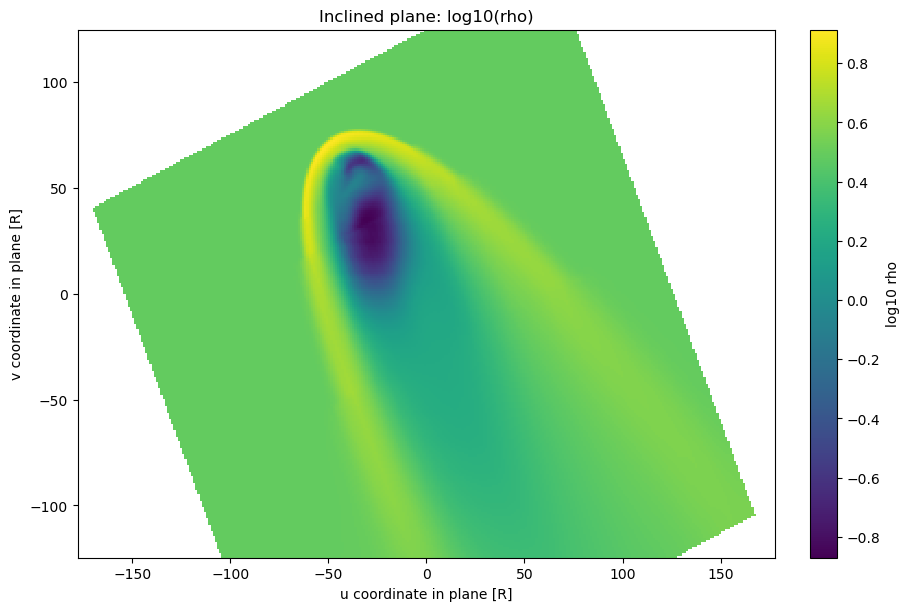

In [4]:
fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
im = ax.pcolormesh(uu, vv, log_rho_plane, shading='auto', cmap='viridis')
ax.set_xlabel('u coordinate in plane [R]')
ax.set_ylabel('v coordinate in plane [R]')
ax.set_title('Inclined plane: log10(rho)')
cb = fig.colorbar(im, ax=ax)
cb.set_label('log10 rho')
plt.show()


## Resample to a Sphere

Resolution: `180 x 360` (`theta x phi`) points.


In [5]:
radii = np.linalg.norm(xyz, axis=1)
r_sphere = float(np.nanpercentile(radii, 42.0))

n_theta, n_phi = 180, 360
theta = np.linspace(0.0, np.pi, n_theta)
phi = np.linspace(0.0, 2.0 * np.pi, n_phi, endpoint=False)
pp, tt = np.meshgrid(phi, theta, indexing='xy')

x_s = r_sphere * np.sin(tt) * np.cos(pp)
y_s = r_sphere * np.sin(tt) * np.sin(pp)
z_s = r_sphere * np.cos(tt)

sphere_xyz = np.column_stack((x_s.ravel(), y_s.ravel(), z_s.ravel()))
rho_sphere, cell_sphere = interp(sphere_xyz, query_space='xyz', return_cell_ids=True)
rho_sphere = np.asarray(rho_sphere, dtype=float).reshape(n_theta, n_phi)
cell_sphere = np.asarray(cell_sphere, dtype=int).reshape(n_theta, n_phi)

valid_sphere = (cell_sphere >= 0) & (rho_sphere > 0.0)
log_rho_sphere = np.full_like(rho_sphere, np.nan, dtype=float)
log_rho_sphere[valid_sphere] = np.log10(rho_sphere[valid_sphere])

print('sphere radius [R]:', r_sphere)
print('sphere valid fraction:', float(valid_sphere.mean()))


sphere radius [R]: 27.469255541423035
sphere valid fraction: 1.0


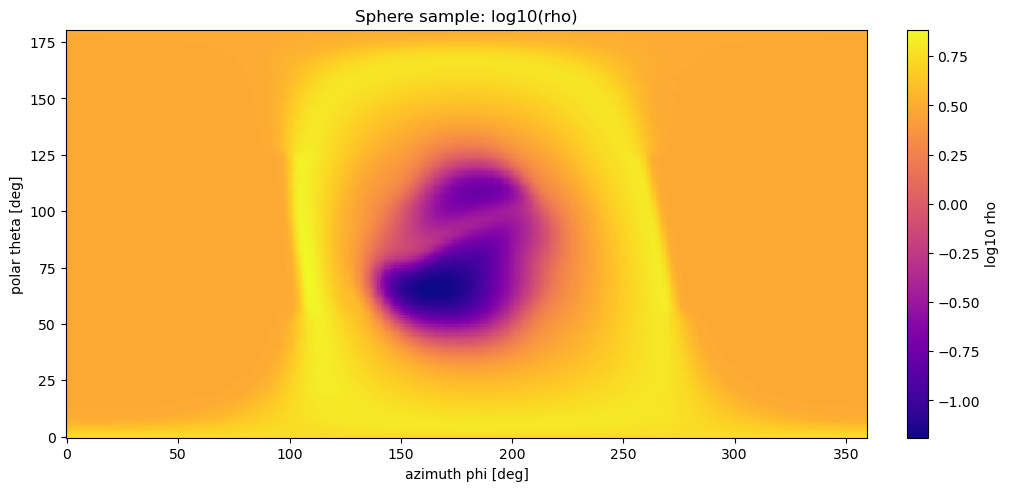

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
im = ax.pcolormesh(np.degrees(pp), np.degrees(tt), log_rho_sphere, shading='auto', cmap='plasma')
ax.set_xlabel('azimuth phi [deg]')
ax.set_ylabel('polar theta [deg]')
ax.set_title('Sphere sample: log10(rho)')
cb = fig.colorbar(im, ax=ax)
cb.set_label('log10 rho')
plt.show()
